# Gated Recurrent Units (GRUs)



By the end of the lesson, all learners will be able to (minimum expected from everyone) :
- Recall the basic architecture of Gated Recurrent Units.
- Find the necessity of using the Gated Recurrent Units for sequential data
- Explore the gates and states that are present in the GRU along with its computational graphs.
- Numerical implementation of Forward Propagation in GRU

To start this lesson **all students must be aware** of the following concepts:

- Sequential Networks
- Workings of Recurrent Neural Networks, LSTM Networks
- Gating Architectures
- Activation Functions like: $Tanh, ReLU, Sigmoid$


Let's just recall about basic flow of GRU, how GRU's reset and update gate perform through computational graph below.






## **Computational Graph of GRU**


<div align="center">

[![GRU-final.png](https://i.postimg.cc/Qdg9Q7Gj/GRU-final.png)](https://postimg.cc/FYRHm7H6)

*figure: GRU Architecture*
</div>

You can see how only the previous hidden state $h_{t-1}$ and input $x_t$ are fed into the cell to get the next hidden state $h_t$. You can also see that there are only two gates.





Lets look at how the GRU works step by step.



## The reset gate



<p>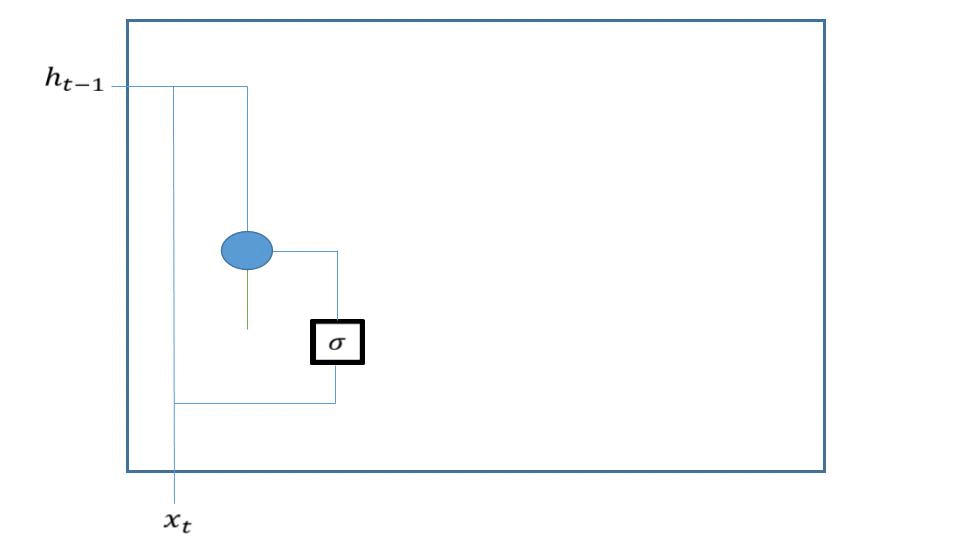</p>

<p align="center">Figure 2. A Reset Gate (Sigmoid)</p>

This gate takes the previous hidden state $h_{t-1}$ and input $x_t$, adds them, and then puts it through a neural network layer with a sigmoid activation. Expressed in mathematical notation, the reset gate will look like this:

$$r_t = \sigma (U_rx_t + W_rh_{t-1} )$$

The weights associated with the hidden state is $W_r$ and $U_r$ is the weights associated with the inputs which are both learned from the data.

 The values of $r_t $ range from zero to one, because of the sigmoid activation. It's role in the GRU cell is to  selects the components of the previous hidden we want to keep. It is analogous to the forget gate in LSTMs.

As you can see in the figure, the outputs from the sigmoid funtion $r_t$ and the previous hidden state $h_{t-1}$ are put through an element wise multiplication. This is denoted by the blue circle. This operation Expressing this as an equation, it would look like:
$$r_t * h_{t-1}$$
* Notice that the values of the previous hidden state $h_{t-1}$ in which the corresponding values of $r_t$ are one are preserved. The components where $r_t$ are zero are discarded.
* Further $r_t$ can have values in between zero and one like 0.8 for example. This is how it is able to control not only which of the previous information is allowed to pass through, but **how much** of is preserved as well.

Now let us look at how new candidate hidden state values are generated using these new values that come after the element wise multiplication.










<p>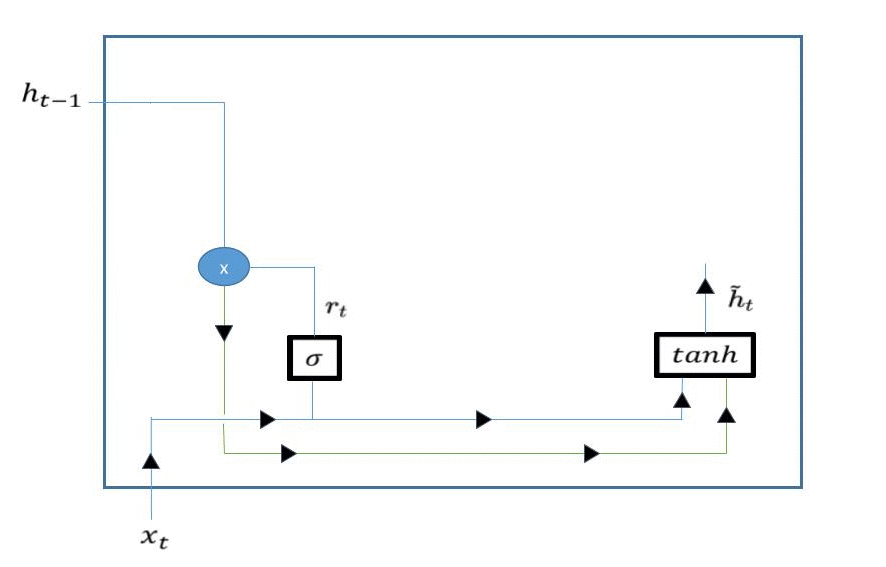</p>

<!--(https://doc.google.com/a/fusemachines.com/uc?export=download&id=1wxeHWhYlFMMJ-4f-2QtvmGtahe6zkRhi)-->


<p align="center">Figure 3. A Reset Gate (Sigmoid and Tanh)

Now, we want to take these selected previous hidden states using $r_t * h_{t-1}$ and use it in conjunction with the input $x_t$ and compute new candidate values for the new timestep.

Hence we add the result $r_t * h_{t-1}$ with the input $x_t$. Then it is put through a $tanh$ activation function to give us these new candidate values. These values are denoted by $\tilde{h_t}$.

Putting all this in one neat equation, we have the following:

$$\tilde{h_t}= tanh( U_cx_t + W_c(h_{t-1}.r_t))$$

Here, $W_c$ is the weights associated with inputs to hidden candidate state and $W_c$ is the weights associated within the hidden candidate states.

Lastly, we will want to have decide the actual output of this cell from these candidate values. We will discuss this in the next section.




## The update gate


This part is what is different about GRUs. Have a look at the following equation:

$$z_t = \sigma (U_zx_t + W_zh_{t-1} )$$

Here, $z_t$ is the result of the update gate. $U_z$ and $W_z$ are the weights associated with input to hidden state and between hidden states.

Also,

$$h_t = z_t * \tilde{h_t} + (1-z_t) * h_{t-1}$$

* We are getting the output of the cell, which is the next hidden state $h_t$.
* You already know what $h_{t-1}$ and $\tilde{h_t}$ stand for:
    * The previous hidden state, and
    * The candidate values for the new hidden state
* Now, $z_t$ is the update gate. It is also a sigmoid so it's value will be between zero and one.
    * If you look at the right of the addition sign, it is controlling how much of the candidate values $\tilde{h_t}$ are passed along to the new hidden state $h_t$. It does so by the element-wise multiplication represented by $*$.
    * The left side of the addition sign has $(1-z_t)$ which is the complement of $z_t$. This controls how much of the previous hidden state is incorporated into the new hidden state.
    * Notice that we have already done this process of choosing information from the previous hidden state to some extent while creating the candidate values $\tilde{h_t}$ using the reset gate $r_t$. But, this is a different operation. Here, we are blending the new candidate values $\tilde{h_t}$ and the previous hidden states $h_{t-1}$ using the update gate $z_t$.




<p>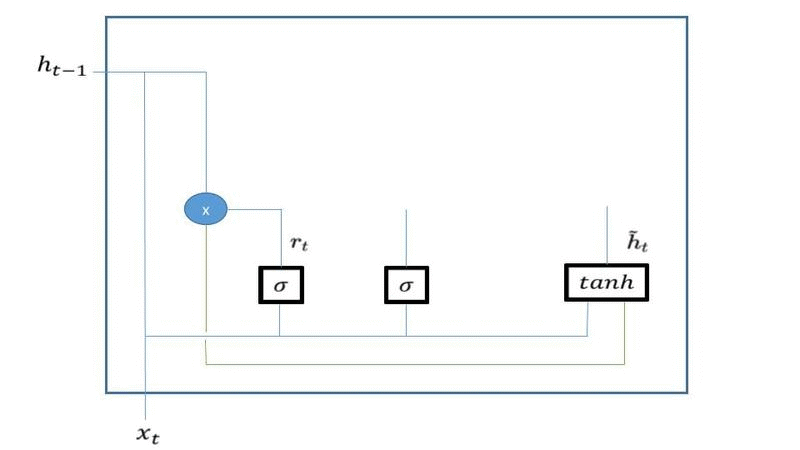</p>

<p align='center'>Figure 5. An Update Gate</p>

Overally, we can conclude that **Update Gate** helps to decide what informations from the previous time steps $h_{t-1}$ can be taken to the next time step $h_t$. They are simply the combination of input gate and the forget gate as studied before in LSTM.


And, **Reset Gate** helps to decide how much of the past information from the previous hidden states can it forget.



## **Forward Propagation in GRU, Numerical Illustration**


Let us perform value estimation while traversing through different gates from the input and previous hidden state to the next hidden state.  

### **1. Reset Gate**
For a reset gate at time step $t$,

$$r_t = \sigma (U_rx_t + W_rh_{t-1} )$$

where,

$W_r$ - weights associated with hidden and reset gates

$U_r$ - weights associated with input and reset gates

$x_t$ - input at the current time step

$h_{t-1}$ - previous hidden state

$r_t$ - output from the reset gate


For easiness in calculation and simple demonstration,

Following are the weights and biases associated with reset gate, update gate and hidden candidate.
$$W_r = 1, W_c = 1, W_z = 1 $$
$$U_r = 1, U_c = 1 $$
$$V = 1$$
$$x_t = 1, h_{t-1} = 0$$



then,

$$r_t = \sigma (U_rx_t + W_rh_{t-1} )$$

$$r_t = \sigma(1.1 + 1.0)$$

$$r_t = \sigma(1)$$

Hence, $$r_t = 0.731058$$


Before going through the update gates, we need to calculate the candidate values for hidden state. Let us recall the following formula:

$$\tilde{h_t}= tanh( U_cx_t + W_c(h_{t-1}.r_t))$$

where,

$W_c$ - weights associated with hidden candidates
$U_c$ - weights associated with input and hidden candidates

then, 0.731058
$$\tilde{h_t}= tanh( U_cx_t + W_c(h_{t-1}.r_t)$$
$$\tilde{h_t}= tanh( 1.1 + 1(0).0.731058$$
$$\tilde{h_t} = tanh(1)$$

Hence,

$$\tilde{h_t} = 0.7615941$$



### **2. Update Gate**

Let's recall the formulas associated with the update gate. For an update gate, we update the following at given time step $t$:

$$z_t = \sigma (U_zx_t + W_zh_{t-1} )$$
$$h_t = z_t * \tilde{h_t} + (1-z_t) * h_{t-1}$$


$U_z$ - weights associated with input and update gate

$W_z$ - weights associated with hidden and update gate

$b_u$ - bias associated with update gate

$z_t$ - output values from update gates


For easiness in calculation and simple demonstration,

then,

$$z_t = \sigma (U_zx_t + W_zh_{t-1} )$$

$$z_t = \sigma (1.1 + 1.0 )$$

$$ z_t = \sigma(1)$$

Hence,

$$ z_t = 0.731058$$

Again,

Let us find the value of current hidden state $h_t$. Recalling the formula on update gate:

$$h_t = z_t * \tilde{h_t} + (1-z_t) * h_{t-1}$$

$$h_t = 0.731058 * 0.7615941 + (1-0.731058) * 0$$

Hence,

$$h_t = 0.556769 $$




Now,

Calulating the output of the GRU cell using the following formula:

$$y = Vh_t$$
$$y = 1 * 0.556769$$
Hence,
$$y = 0.556769$$

With simple values initialisation, we performed forward propagation of a single GRU cell and calculated the hidden state value for time step $t$ and output for the GRU cell.




#  GRU Forward Propagation — Predicting the Next Word (“Nepali”)

We want a GRU to complete the sentence:  

 **“He is fluent in ___”**  

Given the context (`Nepal`, `Nepali songs`, `Nepali books`), the model should predict **“Nepali.”**


##  Step 1: Inputs as Embeddings
Before GRU can process words, they are converted into **embeddings (vectors of numbers).**  

Example embeddings:
- **"Nepal"** → `[0.8, -0.3, 0.6, 0.2]`
- **"Nepali"** → `[0.9, -0.2, 0.7, 0.3]`

These numbers represent hidden features:
- 0.8 → relates to "Country"
- -0.3 → geographical feature
- 0.6 → cultural aspect
- 0.2 → grammatical usage

 Words with similar meanings (Nepal / Nepali) have **similar embeddings**.


**Our input sequence:**  

Words:  
`[John, lived, in, Nepal, …, fluent, in, ___]`

Embeddings:  
`[x₁, x₂, x₃, x₄, …, x₂₁, x₂₂, ?]`

Where for example:  
- `x₁ = [0.2, -0.1, 0.5, 0.1]` → "John"  
- `x₂ = [0.1, 0.3, -0.2, 0.4]` → "lived"  
- `x₃ = [-0.1, 0.4, 0.1, 0.2]` → "in"  
- `x₄ = [0.8, -0.3, 0.6, 0.2]` → "Nepal"  



##  Step 2: Initialize Hidden State
At the beginning, the GRU knows nothing:

\[
h_0 = [0.0, 0.0, 0.0, 0.0]
\]

Think of this as starting a book with an empty mind.



## Step 3: GRU Forward Propagation
At each step `t`, GRU does **4 calculations**:

###  3.1 Reset Gate
$
r_t = \sigma(W_r [h_{t-1}, x_t] + b_r)
$

 *“How much of the past memory should I forget?”*



###  3.2 Update Gate
$
z_t = \sigma(W_z [h_{t-1}, x_t] + b_z)
$

 *“How much should I update with new info?”*


###  3.3 Candidate Hidden State
$
\tilde{h}_t = \tanh(W_h [r_t \odot h_{t-1}, x_t] + b_h)
$

 *“What new candidate memory should I consider?”*



###  3.4 Final Hidden State
$
h_t = (1 - z_t) \odot h_{t-1} + z_t \odot \tilde{h}_t
$

*“Blend old memory with the new candidate.”*



##  Step 4: Example — Processing “Nepal”

- Current input:  
$
  x_4 = [0.8, -0.3, 0.6, 0.2]
 $

- Previous hidden state:  
$
  h_3 = [0.1, 0.2, -0.1, 0.3]
 $



###  Reset Gate
$
r_4 = \sigma([0.7, 0.8, 0.6, 0.9]) \approx [0.67, 0.69, 0.65, 0.71]
$
*Keep most of past memory, forget a little.*


###  Update Gate
$
z_4 = \sigma([0.3, 0.5, 0.8, 0.2]) \approx [0.57, 0.62, 0.69, 0.55]
$

*Update moderately with new info.*



###  Candidate State
Filtered memory:  
$
r_4 \odot h_3 = [0.07, 0.16, -0.06, 0.27]
$

Candidate:  
$
\tilde{h}_4 = \tanh([0.9, -0.4, 0.7, 0.5]) \approx [0.72, -0.38, 0.60, 0.46]
$


###  Final Hidden State
$
h_4 = (1 - z_4) \odot h_3 + z_4 \odot \tilde{h}_4
$

$
h_4 = [0.34, -0.12, 0.49, 0.34]
$

**Meaning:** John is associated with Nepal (place info is stored).



##  Step 5: Pattern Building Through Sequence
- After "John lived in Nepal":  
$
  h_4 = [0.34, -0.12, 0.49, 0.34]
 $

- After "He listens to Nepali songs":  
  $
  h_{13} = [0.42, -0.18, 0.67, 0.51]
 $
- After "He reads Nepali books":  
 $
  h_{18} = [0.58, -0.23, 0.78, 0.63]
 $

- At "He is fluent in":  
$
  h_{21} = [0.71, -0.31, 0.89, 0.77]
$

**Memory now contains:**  
 Nepal + Nepali culture + books + songs → strong signal that the missing word is "Nepali."



##  Step 6: Output Generation
Final hidden state:  
$
h_{21} = [0.71, -0.31, 0.89, 0.77]
$



###  Transform to Vocabulary Scores
$
y = W_{out} \cdot h_{21} + b
$

Example scores:
- "Nepali" → 4.2
- "Hindi" → 1.8  
- "English" → 1.3  
- "Chinese" → 0.9  



###  Convert Scores to Probabilities
Using **softmax**:

$
P(word) = \frac{e^{score}}{\sum e^{score}}
$

Probabilities:
- "Nepali" → **0.87**  
- "Hindi" → 0.05  
- "English" → 0.03  
- "Chinese" → 0.02  



#  Final Prediction
**Predicted Word:** `"Nepali"`  
**Confidence:** 87%



## Summary
- GRU reads input **step by step**.  
- Gates decide how much old info to keep vs. new info to add.  
- After reading the whole sentence, the final hidden state holds the context.  
- From this context, GRU predicts the missing word **“Nepali.”**


# Takeaways
The major takeaways from the lesson are:
- GRUs are the simplified version of LSTM
- GRUs have less no. of parameters due to lesser no. of gates so that they are easier to train.
- GRUs have only two gates and one hidden state.




---

## Resources

**Papers**
- Cho, K., van Merrienboer, B., Gulcehre, C., Bougares, F., Schwenk, H., & Bengio, Y. (2014). Learning phrase representations using RNN encoder-decoder for statistical machine translation. In Conference on Empirical Methods in Natural Language Processing (EMNLP 2014)

- Greff, K., Srivastava, R. K., Koutník, J., Steunebrink, B. R. & Schmidhuber, J. (2015). LSTM: A Search Space Odyssey.. CoRR, abs/1503.04069.

- Chung, J., Gulcehre, C., Cho, K. & Bengio, Y. (2014). Empirical Evaluation of Gated Recurrent Neural Networks on Sequence
Modeling (cite arxiv:1412.3555Comment: Presented in NIPS 2014 Deep Learning and Representation Learning Workshop)



- [Understanding LSTM networks](http://colah.github.io/posts/2015-08-Understanding-LSTMs/)

    
- [Illustrated guide to LSTMs and GRUs](https://towardsdatascience.com/illustrated-guide-to-lstms-and-gru-s-a-step-by-step-explanation-44e9eb85bf21)

